Rows: 1773
Columns: 54

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1773 entries, 0 to 1772
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           1773 non-null   object 
 1   Days for shipping (real)       1773 non-null   int64  
 2   Days for shipment (scheduled)  1773 non-null   int64  
 3   Benefit per order              1773 non-null   float64
 4   Sales per customer             1773 non-null   float64
 5   Delivery Status                1773 non-null   object 
 6   Late_delivery_risk             1773 non-null   int64  
 7   Category Id                    1773 non-null   int64  
 8   Category Name                  1773 non-null   object 
 9   Customer City                  1773 non-null   object 
 10  Customer Country               1773 non-null   object 
 11  Customer Email                 1773 non-null   object 
 12  Cus

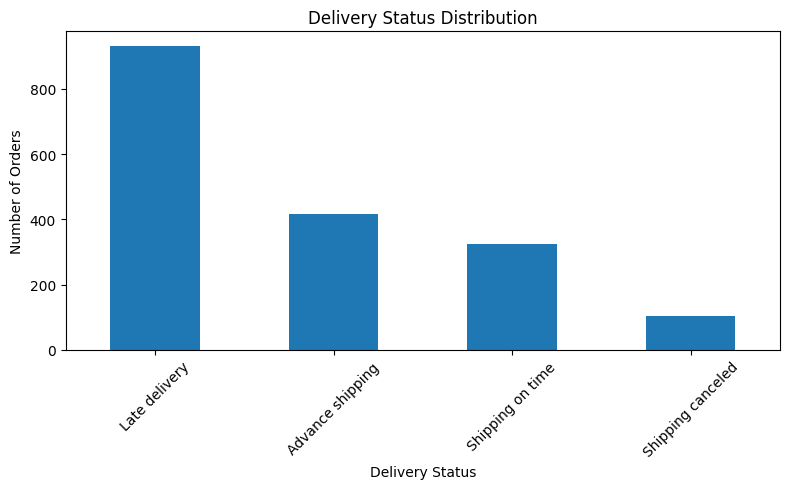

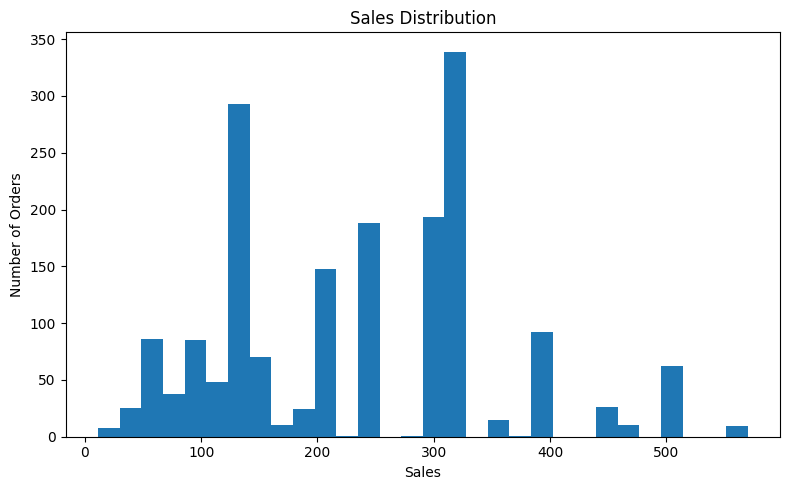

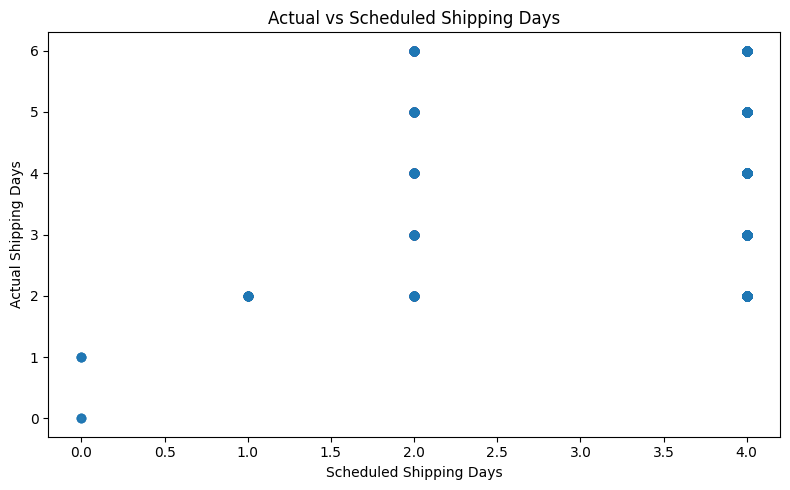

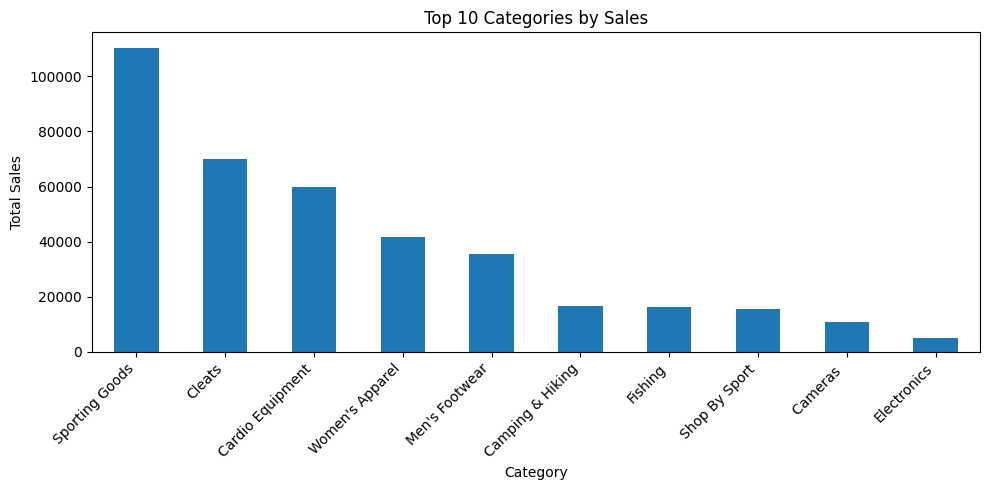

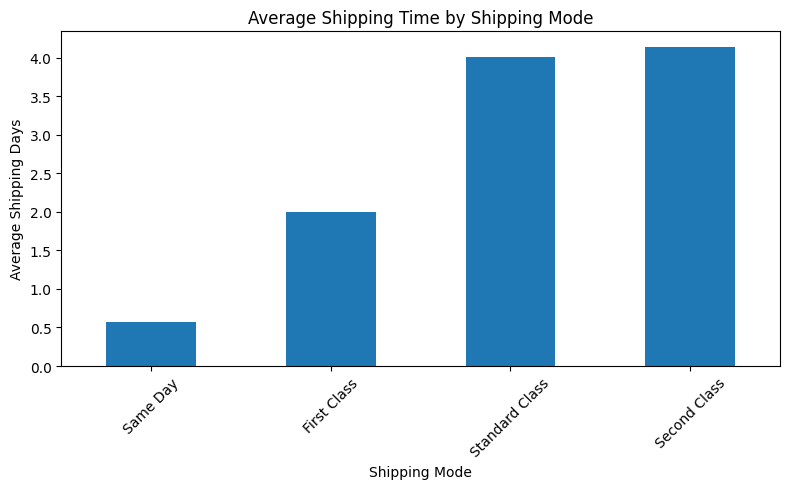

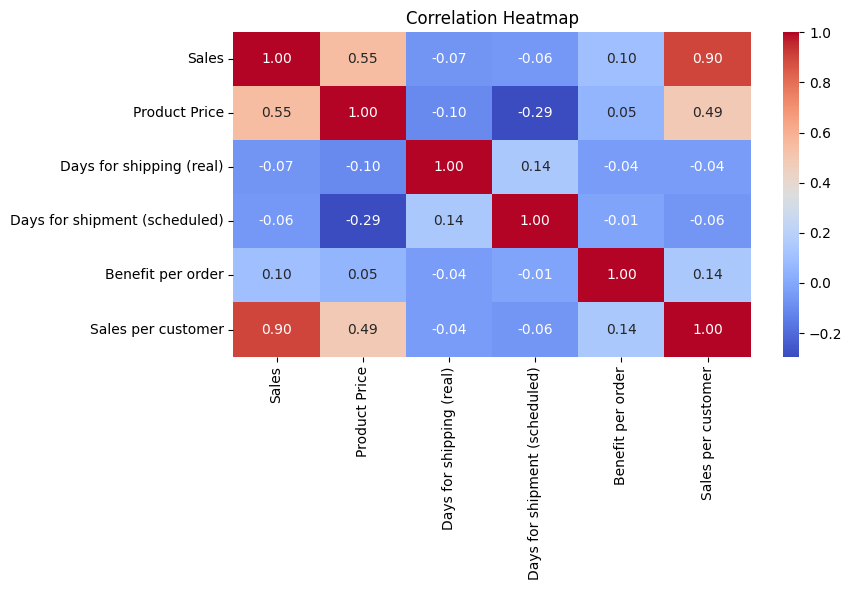

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("/content/DataCoSupplyChainDataset_Cleaned.csv")

# Basic information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Delivery status
print("\nDelivery Status:")
print(df["Delivery Status"].value_counts())

# Average values
print("\nAverage Values:")
print("Average Sales:", round(df["Sales"].mean(), 2))
print("Average Product Price:", round(df["Product Price"].mean(), 2))
print("Average Shipping Days:", round(df["Days for shipping (real)"].mean(), 2))
print("Average Scheduled Shipping Days:", round(df["Days for shipment (scheduled)"].mean(), 2))

# Correlation
num_cols = [
    "Sales",
    "Product Price",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer"
]

print("\nCorrelation:")
print(df[num_cols].corr().round(2))

# 1. Delivery Status
plt.figure(figsize=(8, 5))
df["Delivery Status"].value_counts().plot(kind="bar")
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Sales Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

# 3. Actual vs Scheduled Shipping
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Days for shipment (scheduled)"],
    df["Days for shipping (real)"],
    alpha=0.3
)
plt.title("Actual vs Scheduled Shipping Days")
plt.xlabel("Scheduled Shipping Days")
plt.ylabel("Actual Shipping Days")
plt.tight_layout()
plt.show()

# 4. Top Categories by Sales
top_categories = df.groupby("Category Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_categories.plot(kind="bar")
plt.title("Top 10 Categories by Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5. Shipping Mode vs Delivery Time
shipping_time = df.groupby("Shipping Mode")["Days for shipping (real)"].mean().sort_values()

plt.figure(figsize=(8, 5))
shipping_time.plot(kind="bar")
plt.title("Average Shipping Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [2]:
# More detailed analysis

print("Average Sales:", round(df["Sales"].mean(), 2))
print("Median Sales:", round(df["Sales"].median(), 2))

print("\nAverage Actual Shipping Days:",
      round(df["Days for shipping (real)"].mean(), 2))

print("Average Scheduled Shipping Days:",
      round(df["Days for shipment (scheduled)"].mean(), 2))

print("\nAverage Benefit per Order:",
      round(df["Benefit per order"].mean(), 2))

print("\nTop 5 Categories by Sales:")
print(df.groupby("Category Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(5))

print("\nShipping Mode Average Delivery Time:")
print(df.groupby("Shipping Mode")["Days for shipping (real)"]
      .mean()
      .sort_values())

print("\nDelivery Status Percentage:")
print((df["Delivery Status"].value_counts(normalize=True) * 100).round(2))

Average Sales: 236.29
Median Sales: 239.96

Average Actual Shipping Days: 3.94
Average Scheduled Shipping Days: 3.24

Average Benefit per Order: 24.35

Top 5 Categories by Sales:
Category Name
Sporting Goods      110451.750000
Cleats               70008.412299
Cardio Equipment     60014.040215
Women's Apparel      41750.000000
Men's Footwear       35487.271501
Name: Sales, dtype: float64

Shipping Mode Average Delivery Time:
Shipping Mode
Same Day          0.571429
First Class       2.000000
Standard Class    4.006987
Second Class      4.134545
Name: Days for shipping (real), dtype: float64

Delivery Status Percentage:
Delivery Status
Late delivery        52.45
Advance shipping     23.46
Shipping on time     18.27
Shipping canceled     5.81
Name: proportion, dtype: float64


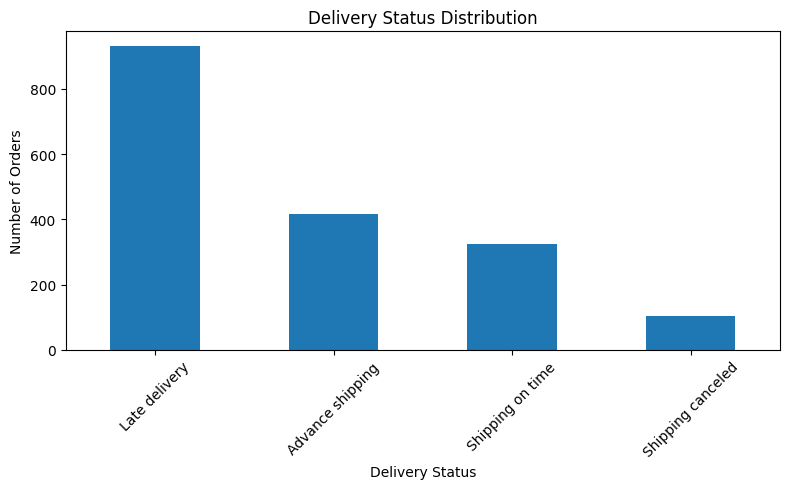

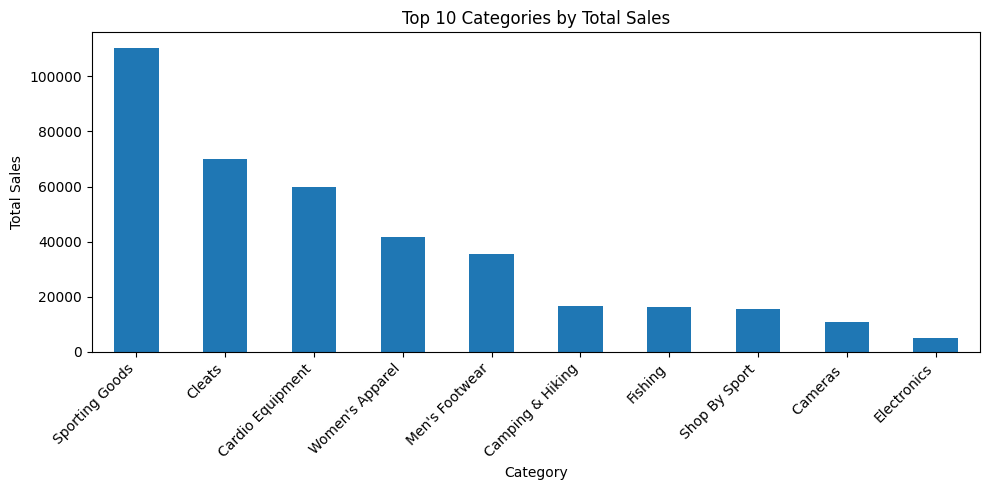

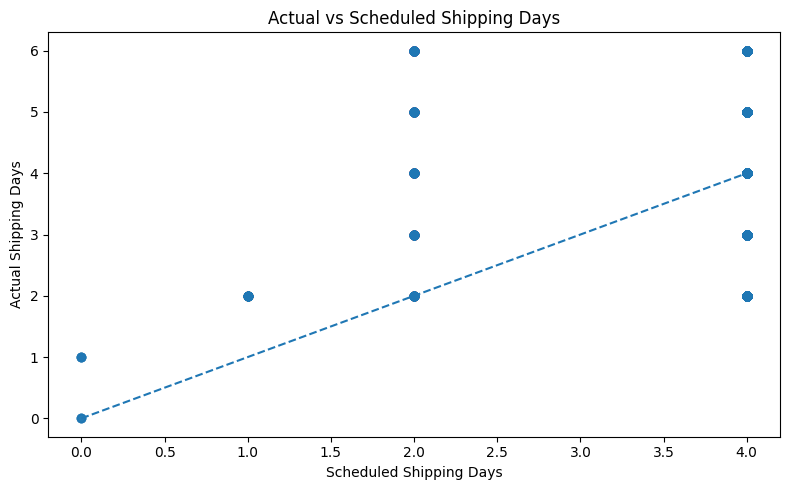

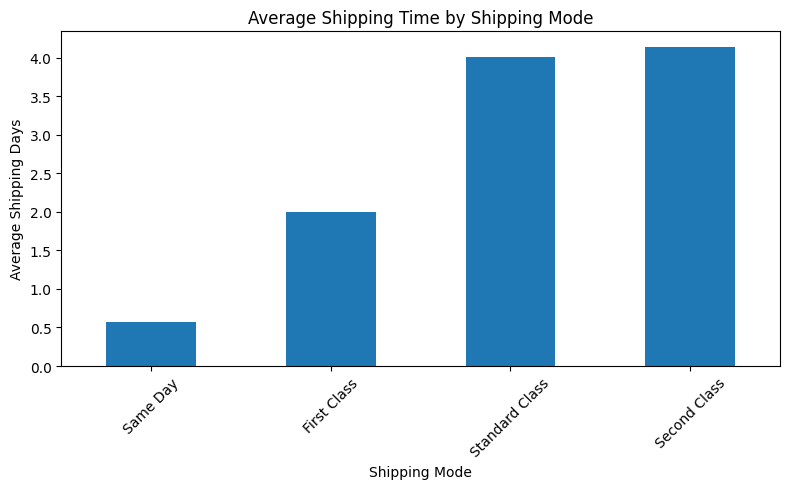

In [3]:
# More visualizations

# 1. Delivery Status Percentage
status = df["Delivery Status"].value_counts()

plt.figure(figsize=(8, 5))
status.plot(kind="bar")
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Top 10 Categories by Sales
category_sales = df.groupby("Category Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
category_sales.plot(kind="bar")
plt.title("Top 10 Categories by Total Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 3. Actual vs Scheduled Shipping Days
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Days for shipment (scheduled)"],
    df["Days for shipping (real)"],
    alpha=0.3
)

plt.plot(
    [df["Days for shipment (scheduled)"].min(),
     df["Days for shipment (scheduled)"].max()],
    [df["Days for shipment (scheduled)"].min(),
     df["Days for shipment (scheduled)"].max()],
    linestyle="--"
)

plt.title("Actual vs Scheduled Shipping Days")
plt.xlabel("Scheduled Shipping Days")
plt.ylabel("Actual Shipping Days")
plt.tight_layout()
plt.show()


# 4. Shipping Mode Comparison
shipping = df.groupby("Shipping Mode")["Days for shipping (real)"].mean().sort_values()

plt.figure(figsize=(8, 5))
shipping.plot(kind="bar")
plt.title("Average Shipping Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

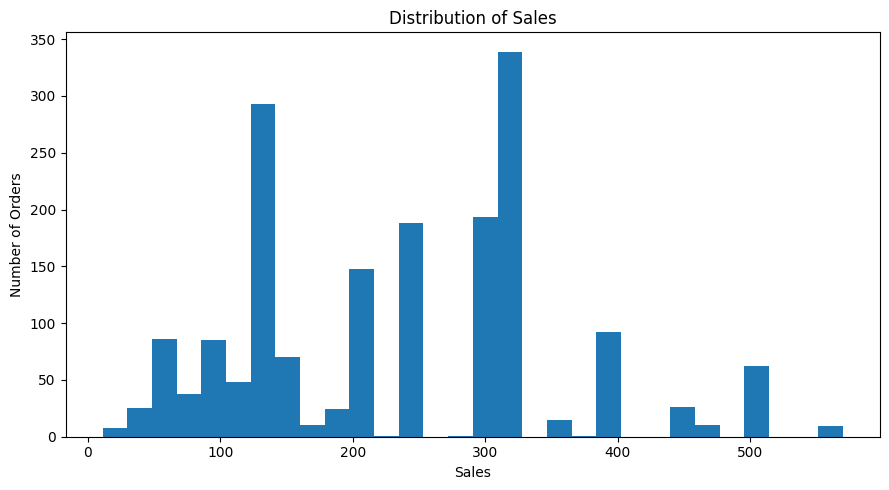

In [4]:
# Sales Distribution

plt.figure(figsize=(9, 5))

plt.hist(df["Sales"], bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

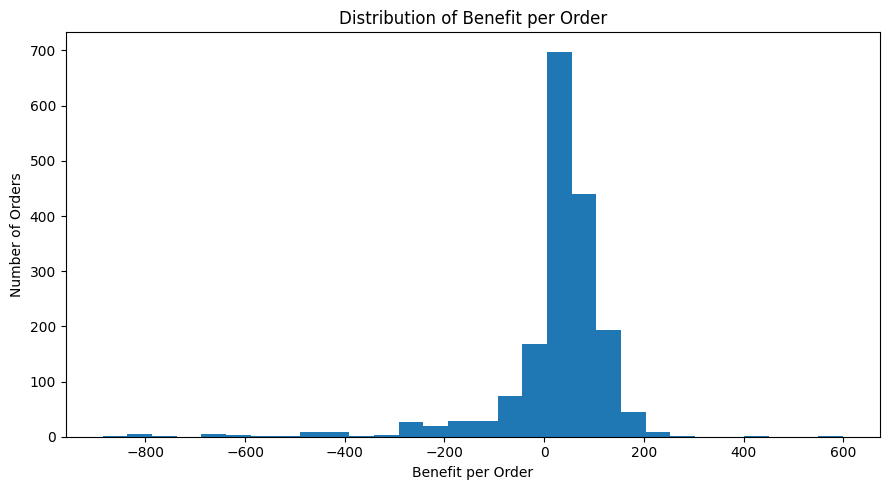

In [5]:
# Benefit per Order Distribution

plt.figure(figsize=(9, 5))

plt.hist(df["Benefit per order"], bins=30)

plt.title("Distribution of Benefit per Order")
plt.xlabel("Benefit per Order")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [6]:
# Key Analytical Insights

print("KEY ANALYTICAL INSIGHTS")
print("-" * 50)

print(f"1. Average sales per order: {df['Sales'].mean():.2f}")
print(f"2. Median sales per order: {df['Sales'].median():.2f}")

print(f"\n3. Average actual shipping time: "
      f"{df['Days for shipping (real)'].mean():.2f} days")

print(f"4. Average scheduled shipping time: "
      f"{df['Days for shipment (scheduled)'].mean():.2f} days")

delay_gap = (
    df['Days for shipping (real)'].mean()
    - df['Days for shipment (scheduled)'].mean()
)

print(f"5. Average shipping delay: {delay_gap:.2f} days")

print(f"\n6. Average benefit per order: "
      f"{df['Benefit per order'].mean():.2f}")

print("\n7. Top 5 categories by sales:")
print(
    df.groupby("Category Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .round(2)
)

print("\n8. Delivery status percentage:")
print(
    (df["Delivery Status"].value_counts(normalize=True) * 100)
    .round(2)
)

KEY ANALYTICAL INSIGHTS
--------------------------------------------------
1. Average sales per order: 236.29
2. Median sales per order: 239.96

3. Average actual shipping time: 3.94 days
4. Average scheduled shipping time: 3.24 days
5. Average shipping delay: 0.70 days

6. Average benefit per order: 24.35

7. Top 5 categories by sales:
Category Name
Sporting Goods      110451.75
Cleats               70008.41
Cardio Equipment     60014.04
Women's Apparel      41750.00
Men's Footwear       35487.27
Name: Sales, dtype: float64

8. Delivery status percentage:
Delivery Status
Late delivery        52.45
Advance shipping     23.46
Shipping on time     18.27
Shipping canceled     5.81
Name: proportion, dtype: float64


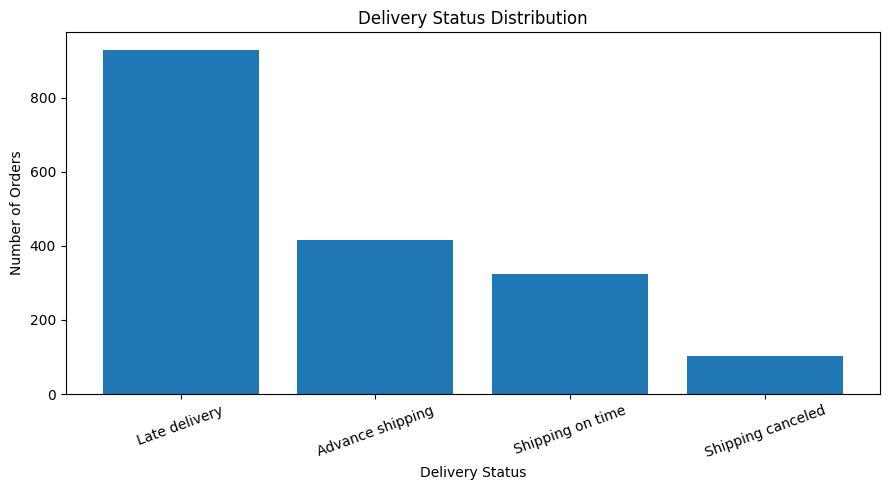

In [7]:
# Delivery Status Distribution

status_counts = df["Delivery Status"].value_counts()

plt.figure(figsize=(9, 5))

plt.bar(status_counts.index, status_counts.values)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()